In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

sc.settings.verbosity = 2

In [2]:
CLUSTER_PALETTE = {
    "R1": "#FCAE91",
    "R2": "#FB6A4A",
    "R3": "#CB181D",
}


def load_and_merge_capybara(adata, fpath_scale):
    df = pd.read_csv(fpath_scale)
    df = df.set_index("cell_name")

    common_cells = adata.obs.index.intersection(df.index)
    print(f"Merging on {len(common_cells)} shared cells")

    adata.obs = adata.obs.join(df, how="left")
    return adata


def drop_clusters(adata, clusters=("C4", "C5")):
    adata = adata[~adata.obs["cluster"].isin(clusters)].copy()
    print(adata.obs["cluster"].value_counts())
    return adata


def plot_predictions_by_cluster(
    adata,
    cell_types,
    palette=CLUSTER_PALETTE,
    replace_underscore=False,
    capitalize=False,
    dpi=None,
):
    df = adata.obs.copy()
    frxn_cols = [col for col in df.columns if col.startswith("frxn_")]

    df_melted = df.melt(
        id_vars=["cluster"],
        value_vars=frxn_cols,
        var_name="Cell Type",
        value_name="Fraction",
    )
    df_melted = df_melted[df_melted["Cell Type"].isin(cell_types)]

    g = sns.FacetGrid(
        df_melted,
        col="Cell Type",
        hue="Cell Type",
        col_wrap=5,
        sharey=True,
        height=2,
        aspect=0.85,
    )
    g.map_dataframe(
        sns.boxplot,
        x="cluster",
        y="Fraction",
        hue="cluster",
        order=sorted(df["cluster"].unique()),
        palette=palette,
        width=0.65,
        linecolor="k",
        capprops={"linewidth": 0},
        showfliers=False,
        linewidth=0.8,
        dodge=False,
    )

    g.set_axis_labels("", "identity score")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=0, labelsize=8)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        title = ax.get_title().split("frxn_")[1]
        if len(title) > 20:
            title = "\n".join(title.split(maxsplit=1))
        if replace_underscore:
            title = title.replace("_", " ")
        if capitalize:
            title = title[0].upper() + title[1:]
        ax.set_title(title, fontsize=9)

    g.fig.subplots_adjust(wspace=0.2)
    if dpi:
        plt.rcParams["figure.dpi"] = dpi
    plt.tight_layout()
    plt.show()
    return g

# Ng Data

In [3]:
%%time
# h5ad built in Hematokytos/anndatas/integrate_scfib_ihsc.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/fib_ihsc_processed.h5ad"
adata = sc.read_h5ad(fpath)

print(adata)

fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/ng_scale.csv"
adata = load_and_merge_capybara(adata, fpath_scale)
adata = drop_clusters(adata)

AnnData object with n_obs × n_vars = 15317 × 23434
    obs: 'batch', 'barcoded_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'cluster'
    var: 'gene_id', 'gene_type', 'Chromosome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'batch_colors', 'cluster_colors', 'dr

## Predictions by Cluster

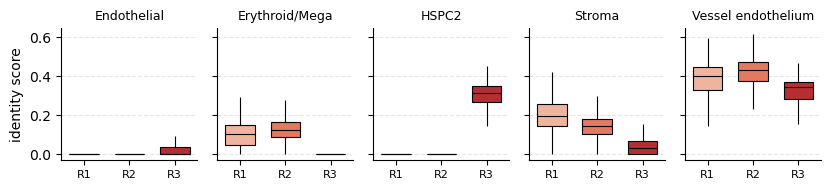

In [4]:
ng_cell_types = [
    "frxn_Endothelial",
    "frxn_Erythroid/Mega",
    "frxn_HSPC2",
    "frxn_Stroma",
    "frxn_Vessel_endothelium",
]
plot_predictions_by_cluster(adata, ng_cell_types, replace_underscore=True, dpi=150)

# Gomes Data

In [5]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/fib_ihsc_processed.h5ad"
adata = sc.read_h5ad(fpath)

fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/gomes_scale.csv"
adata = load_and_merge_capybara(adata, fpath_scale)
adata = drop_clusters(adata)

Merging on 15317 shared cells
cluster
R2    4343
R1    1986
R3     524
Name: count, dtype: int64
CPU times: user 800 ms, sys: 3.26 s, total: 4.06 s
Wall time: 7.02 s


## Predictions by Cluster

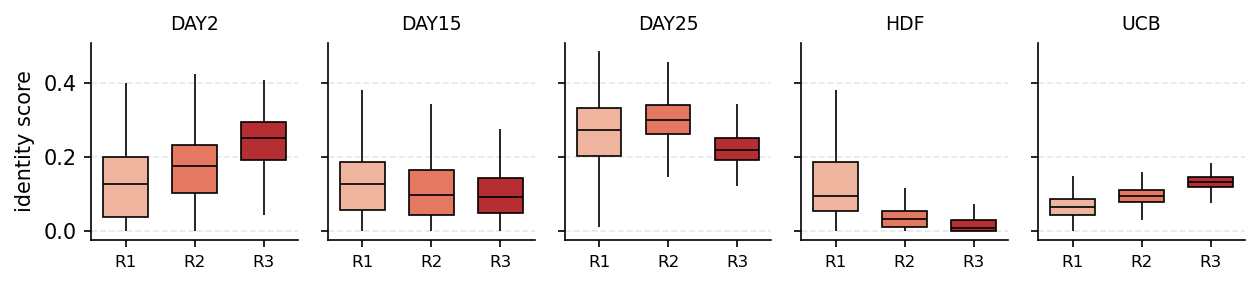

In [6]:
gomes_cell_types = [col for col in adata.obs.columns if col.startswith("frxn_")]
plot_predictions_by_cluster(adata, gomes_cell_types, dpi=150)

# Reference Atlas Data

In [7]:
%%time
# h5ad built in Hematokytos/anndatas/integrate_scfib_ihsc.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/fib_ihsc_processed.h5ad"
adata = sc.read_h5ad(fpath)

fpath_scale = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/celltype_simplified_scale.csv"
adata = load_and_merge_capybara(adata, fpath_scale)
adata = drop_clusters(adata)

Merging on 15317 shared cells
cluster
R2    4343
R1    1986
R3     524
Name: count, dtype: int64
CPU times: user 886 ms, sys: 3.18 s, total: 4.06 s
Wall time: 6.88 s


## Predictions by Cluster

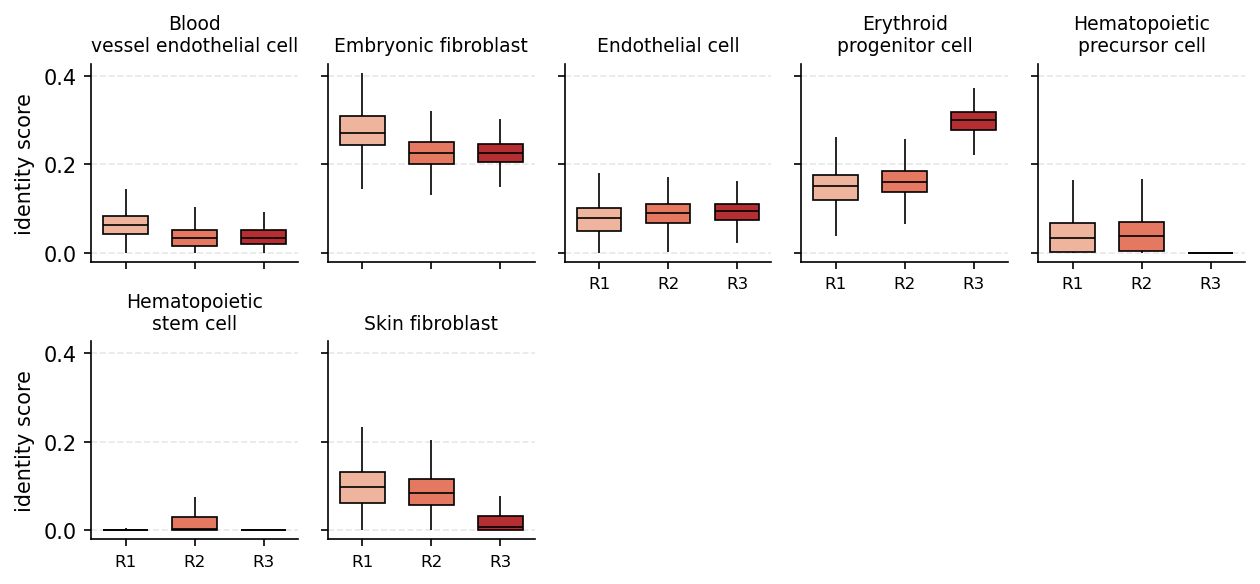

In [8]:
atlas_cell_types = [
    "frxn_skin fibroblast",
    "frxn_hematopoietic stem cell",
    "frxn_hematopoietic precursor cell",
    "frxn_fibroadipogenic progenitor cell",
    "frxn_erythroid progenitor cell",
    "frxn_endothelial cell",
    "frxn_embryonic fibroblast",
    "frxn_blood vessel endothelial cell",
]
plot_predictions_by_cluster(adata, atlas_cell_types, capitalize=True, dpi=150)